Здесь я экспериментирую с feature extraction. Я и тренирую здесь простые модели, но только для оценки полезности признаков, разработкой собственно модели можно будет заняться только позднее.

In [58]:
import polars as pl
dataset = pl.read_csv(
    '../data/processed/train.csv'
)


In [59]:
SEED = 42


In [60]:
dataset.columns


['StimSite',
 'Stimulus',
 'RT_start',
 'Response_annot',
 'Response_transcription_annot',
 'Error_type_annot',
 'error_type_label']

In [61]:
dataset_0 = dataset[[
    'Stimulus',
    'RT_start',
    'Response_annot',
    'Response_transcription_annot',
    'error_type_label'
    ]]

dataset_0[['RT_start']] = dataset_0[['RT_start']]\
                          .fill_null(strategy='zero')

dataset_0[['Response_annot']] = dataset_0[['Response_annot']]\
                        .fill_null('')

dataset_0[['Response_transcription_annot']] =\
      dataset_0[['Response_transcription_annot']].fill_null('')

# мы не хотим получать подсказки в виде #нрзб# и прочих особенностей
# разметки в транскрипте, т. к. они не всегда могут быть доступны
dataset_0 = dataset_0.with_columns(
    pl.col('Response_annot').str.to_lowercase()\
        .str.replace_all(r'[^а-яё ]', '')\
        .str.replace_all('нрзб', '')
)


Различные способы заполнения слабо влияют на метрики по результатам части 1, но при заполнении нулями метрики для классов, которые ожидаемо выявляются по признаку `RT_start`, оказываются немного выше.

# 1. Длина ответа относительно длины стимула

Без транскрипций, потому что они очень сильно неоправданно подсказывают тип ошибки.

In [62]:
dataset_1 = dataset_0.with_columns(
                            (pl.col('Response_annot').str.len_chars() /
                            pl.col('Stimulus').str.len_chars())\
                            .fill_null(0)\
                            .alias('relative_length')
                            )


In [63]:
from json import load

error_type_ids_file = open('../data/processed/error_type_ids.json',
                        'r', -1, 'utf-8')
error_type_ids = load(error_type_ids_file)
print(*error_type_ids.items(), sep='\n')
error_type_ids_to_names: list[str] = [''] * 8
for k, v in error_type_ids.items():
    error_type_ids_to_names[v] = k


('нет', 0)
('speech arrest', 1)
('аномия', 2)
('дизартрия', 3)
('задержка', 4)
('поиск слова', 5)
('семантическая парафазия', 6)
('фонетическая парафазия', 7)


In [64]:
X = dataset_1[['relative_length', 'RT_start']]
y = dataset_1['error_type_label']


In [65]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score,\
                                                    confusion_matrix
from matplotlib.pyplot import imshow, ylabel, xlabel, yticks, xticks
import numpy as np

def evaluate(X, y: pl.Series, estimator: Pipeline = Pipeline([
            ('classifier', DecisionTreeClassifier(random_state=SEED))])
        ):
    # relative_length и RT_start — разного масштаба, для
    # линейных моделей здесь был бы скейлер
    k = 5
    stratified_k_fold = StratifiedKFold(n_splits = k, # test 20%
                                        shuffle = True,
                                        random_state=SEED)
    number_of_classes = y.n_unique()
    classes_met = y.unique().sort()
    error_type_ids_to_names_ = [name for i, name
                                in enumerate(error_type_ids_to_names)
                                if i in classes_met]

    f1s = np.zeros((k, number_of_classes))
    precisions = f1s.copy()
    recalls = f1s.copy()
    confusion_matrices = np.zeros((k, number_of_classes, 
                                   number_of_classes))
    
    for i, (train_mask, test_mask) in\
                    enumerate(stratified_k_fold.split(X, y)):
        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]
        estimator.fit(X_train, y_train)
        predictions = estimator.predict(X_test)
        f1s[i] = f1_score(y_test, predictions, average=None)
        precisions[i] = precision_score(y_test, predictions,
                                         average=None)
        recalls[i] = recall_score(y_test, predictions, average=None)
        confusion_matrices[i] = confusion_matrix(y_test, predictions)

    np.set_printoptions(suppress=True)

    def _tabs(cell):
        return cell + '\t' * (3 - len(cell) // 8)

    print('Класс\t\t\tPrec.\tRec.\tF1')
    print(*('%s%.4f\t%.4f\t%.4f' % (_tabs(name),
             precision.item(),
             recall.item(),
             f1.item())
            for name, precision, recall, f1
            in zip(error_type_ids_to_names_,
                   precisions.mean(axis=0),
                   recalls.mean(axis=0),
                   f1s.mean(axis=0))), 
            sep='\n')
    
    confusion_matrix_mean = confusion_matrices.mean(axis = 0).round(2)
    confusion_matrix_normalized = confusion_matrix_mean / \
                    confusion_matrix_mean.max(axis=1, keepdims=True)
    imshow(confusion_matrix_normalized)
    ylabel('Истина')
    xlabel('Предсказание')
    yticks(range(number_of_classes), error_type_ids_to_names_)
    xticks(range(number_of_classes), error_type_ids_to_names_, 
           rotation=45)
    return f1s.mean(axis=0), precisions.mean(axis=0), recalls.mean(axis=0)



In [66]:
# import re

# def get_replacement_pairs(**kwargs):
#     stimulus = kwargs['Stimulus']
#     response = kwargs['Response_annot']
#     return [(stimulus[i], response[j])
#             for tag, i, j in Levenshtein.editops(stimulus, 
#                                             response)
#             if tag == 'replace']


Класс			Prec.	Rec.	F1
нет			0.9296	0.9661	0.9475
speech arrest		0.5050	1.0000	0.6681
аномия			0.8257	0.6240	0.7059
дизартрия		0.1939	0.0839	0.1148
задержка		0.4718	0.3618	0.4085
поиск слова		0.1867	0.1364	0.1551
семантическая парафазия	0.1419	0.1085	0.1217
фонетическая парафазия	0.0537	0.0236	0.0325


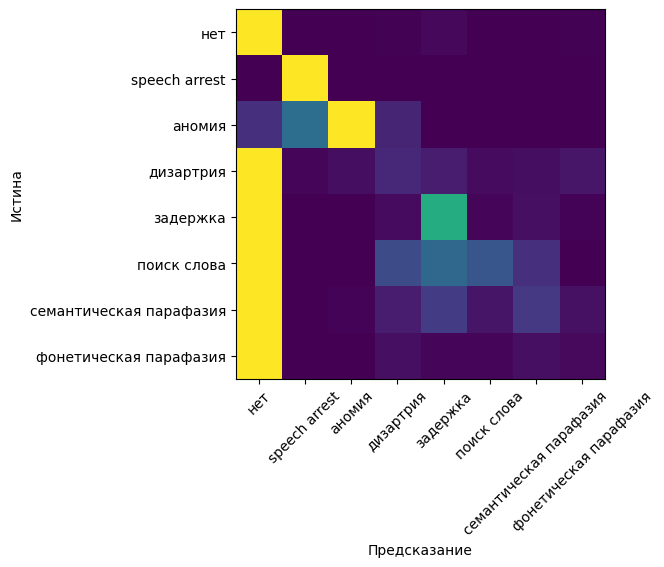

In [67]:
_ = evaluate(X, y)


# 2. Расстояние Левенштейна между стимулом и ответом

## Простейший случай
Сначала посмотрим на полезность доли вставок, удалений и замен. Доли, потому что стимулы могут быть разной длины, и для них будет в разной степени критично одно и то же абсолютное количество замен.

In [68]:
from rapidfuzz.distance import Levenshtein

def indelrep(stimulus, response) -> tuple[int, int, int]:
    edit_operations = Levenshtein.editops(stimulus, response)
    operation_counts = [0] * 3
    operation_ids = dict(zip(['insert', 'delete', 'replace'], range(3)))
    for tag, _, _ in edit_operations:
        operation_counts[operation_ids[tag]] += 1
    return tuple(count / len(stimulus) for count in operation_counts)

print(indelrep('роман', 'роамн'))


(0.2, 0.2, 0.0)


In [69]:
dataset_2 = dataset_1

In [70]:
dataset_2 = dataset_2.with_columns(
    pl.struct(['Stimulus', 'Response_annot'])
    .map_elements(
        lambda s: indelrep(s['Stimulus'], s['Response_annot']), 
        return_dtype=pl.Struct([
            pl.Field('insertions', pl.Float64),
            pl.Field('deletions', pl.Float64),
            pl.Field('replacements', pl.Float64)
        ])
    )
    .alias('edit_distance_components')
).unnest('edit_distance_components')


Класс			Prec.	Rec.	F1
нет			0.9401	0.9638	0.9518
speech arrest		0.5050	1.0000	0.6681
аномия			0.8510	0.6333	0.7132
дизартрия		0.1781	0.0903	0.1196
задержка		0.4769	0.4035	0.4366
поиск слова		0.2425	0.2030	0.2172
семантическая парафазия	0.1740	0.1579	0.1652
фонетическая парафазия	0.3143	0.2247	0.2595


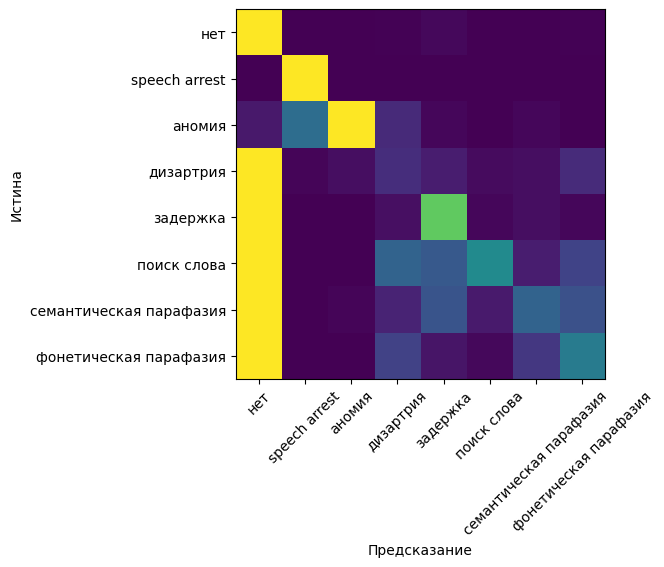

In [71]:
X = dataset_2[['RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']
_ = evaluate(X, y)


Как и предполагалось, стало лучше с нахождением фонетической парафазии и, в меньшей степени, дизартрии и задержки, но всё ещё не так хорошо. Без моего намерения, хотя и объяснимо, поднялась метрика для семантической парафазии и поиска слова.



Отдельно проверим поинты, для которых есть транскрипция.

In [72]:
dataset_2_t = dataset_2\
    .filter(pl.col('Response_transcription_annot').str.len_chars() > 0)\
    .with_columns(
    pl.struct(['Stimulus', 'Response_transcription_annot'])
    .map_elements(
        lambda s: indelrep(s['Stimulus'],
                           s['Response_transcription_annot']), 
        return_dtype=pl.Struct([
            pl.Field('insertions_transcription', pl.Float64),
            pl.Field('deletions_transcription', pl.Float64),
            pl.Field('replacements_transcription', pl.Float64)
        ])
    )
    .alias('edit_distance_components_transcription')
).unnest('edit_distance_components_transcription')


Класс			Prec.	Rec.	F1
нет			0.1161	0.1145	0.1134
аномия			0.7856	0.8464	0.8102
дизартрия		0.3578	0.3582	0.3570
задержка		0.7293	0.7338	0.7314
поиск слова		0.1682	0.1764	0.1702
семантическая парафазия	0.2053	0.2390	0.2173
фонетическая парафазия	0.4550	0.4156	0.4341


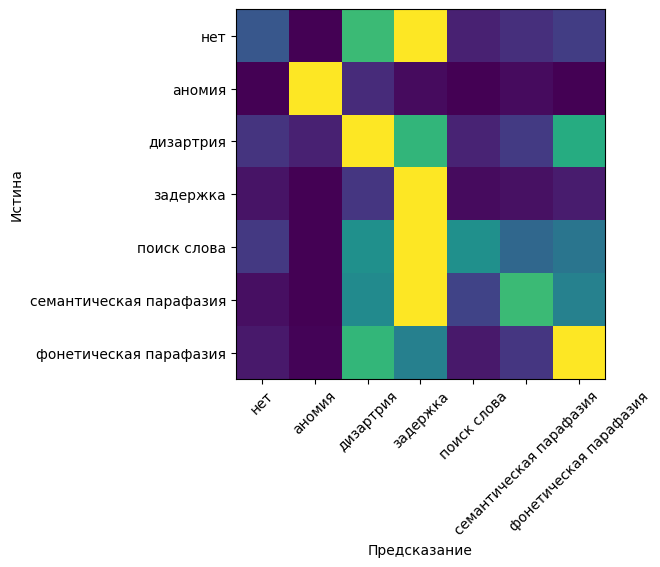

In [73]:
X = dataset_2_t[['RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2_t['error_type_label']
_ = evaluate(X, y)


## Отдельные замены

Найдём самые частотные замены, оставим только их количество для каждого поинта, натренируем модель и посмотрим, как она справится. Тут возникнет две проблемы:
 + Матрица признаков будет разреженной; нужно будет или поднять порог частотности, или выбрать классификатор, который хорошо с таким работает.
 + Нужно писать свой трансформер для sklearn, потому что считать частотность по-хорошему надо каждый раз на тренировочной выборке, а не на датасете целиком, чтобы избежать утечки распределения. Это будет полезно позже, когда все операции над датасетом надо будет проводить в пайплайне.

In [74]:
def get_replacement_pairs(stimulus, response):
    return [(stimulus[i], response[j])
            for tag, i, j in Levenshtein.editops(stimulus, 
                                            response)
            if tag == 'replace']


In [75]:
get_replacement_pairs('штегрусым', 'это штеграсым')


[('у', 'а')]

In [76]:
from numpy import ndarray
from sklearn.base import BaseEstimator, TransformerMixin
from collections import Counter

class ReplacementCounter(BaseEstimator, TransformerMixin):
    def __init__(self, columns, max_features=10000,
                 use_transcription=False):
        self.columns = columns
        self.max_features = max_features
        self.use_transcription = use_transcription

    def _counts(self, X: pl.DataFrame | np.ndarray):
        if not ('Stimulus' in X.columns and\
                'Response_annot' in X.columns and\
                (not self.use_transcription or \
                 'Response_transcription_annot' in X.columns
                 )):
            raise TypeError('Нет ожидаемых колонок')
        new_rows = []
        for row in X\
            .with_row_index('id')\
            .to_dicts():
            pairs = Counter()
            pairs.update([f'replacements_{l1}_{l2}' \
                        for l1, l2 in get_replacement_pairs(
                                row['Stimulus'], row['Response_annot']
                            )])
            if self.use_transcription:
                pairs.update([f'replacements_{l1}_{l2}_t' \
                            for l1, l2 in get_replacement_pairs(
                                    row['Stimulus'],
                                    row['Response_transcription_annot']
                                )])
            row.update(pairs.items())
            new_rows.append(row)
        return pl.from_dicts(new_rows)
    
    def fit(self, X: pl.DataFrame | np.ndarray, y = None):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.columns)
        columns_before = X.columns
        columns_to_pass = ['Stimulus',
                            'Response_annot']
        if self.use_transcription:
            columns_to_pass += ['Response_transcription_annot']
        X = self._counts(X[columns_to_pass])
        self.top_columns = \
            X.select(pl.all()\
                .exclude(pl.String)\
                .sum()
            )\
            .unpivot()\
            .sort('value', descending=True)\
            .head(self.max_features + 1)
        # print(self.top_columns)
        self.feature_columns = self.top_columns\
            .get_column('variable')\
            .to_list()
        self.columns_to_leave = columns_before + self.feature_columns
        return self
    def transform(self, X):
        if type(X) != pl.DataFrame:
            X = pl.from_numpy(X, self.columns)
        counts = self._counts(X)
        counts = counts.with_columns(
                [pl.lit(None, dtype=pl.Int64).alias(c) 
                for c in self.feature_columns
                if c not in counts.columns]
            )\
            .select(self.feature_columns)
        # print(counts)
        return X.with_row_index('id')\
            .join(counts, on='id', how='left', coalesce=True)\
            .fill_null(0)\
            .drop('id')\
            .drop(pl.selectors.string())


In [77]:
replacement_counter = ReplacementCounter(dataset_2.columns)
replacement_counter.fit(dataset_2)
replacement_counter.transform(dataset_2[:20])


RT_start,error_type_label,relative_length,insertions,deletions,replacements,replacements_р_т,replacements_е_ё,replacements_а_и,replacements_к_т,replacements_е_и,replacements_к_н,replacements_я_е,replacements_е_,replacements_и_ы,replacements_р_о,replacements_б_ш,replacements_ю_а,replacements_л_т,replacements_б_,replacements_о_а,replacements_о_е,replacements_у_о,replacements_п_т,replacements_и_о,replacements_к_э,replacements_я_о,replacements_г_,replacements_к_б,replacements_у_ж,replacements_ш_а,replacements_к_в,replacements_у_ц,replacements_в_о,replacements_а_,replacements_а_м,replacements_к_е,replacements_ц_т,replacements_с_,replacements_с_л,replacements_п_,replacements_а_э,replacements_о_т,replacements_б_л,replacements_в_э,replacements_л_ж,replacements_у_к,replacements_ш_м,replacements_в_р,replacements_н_о,replacements_д_,replacements_ж_к,replacements_к_ш,replacements_и_б,replacements_б_з,replacements_я_к,replacements_м_и,replacements_с_к,replacements_д_э,replacements_о_э
i64,i64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
711,0,1.5,0.5,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
744,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
681,0,1.8,0.8,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1333,0,1.0,0.125,0.125,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1265,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
701,0,1.666667,0.666667,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
777,0,1.571429,0.571429,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
787,0,2.0,1.0,0.0,0.833333,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0


Класс			Prec.	Rec.	F1
нет			0.9411	0.9615	0.9512
speech arrest		0.5050	1.0000	0.6681
аномия			0.8292	0.6883	0.7475
дизартрия		0.1803	0.0968	0.1256
задержка		0.4784	0.4092	0.4408
поиск слова		0.2443	0.2212	0.2281
семантическая парафазия	0.1975	0.1796	0.1874
фонетическая парафазия	0.3304	0.2838	0.3035


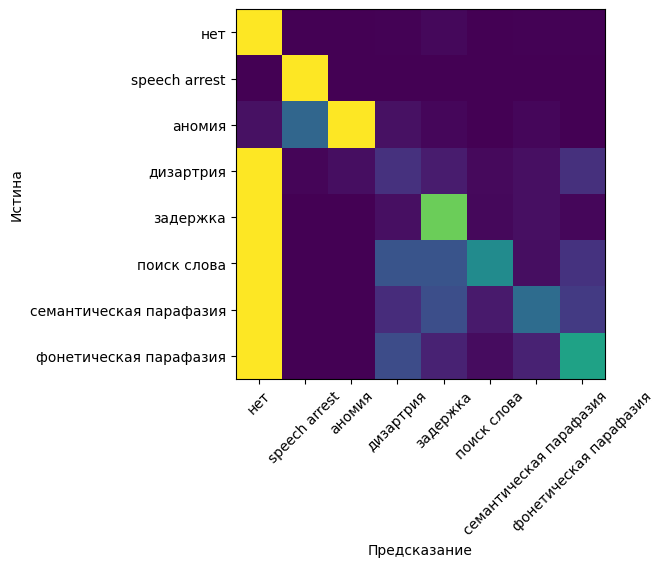

In [78]:
new_pipeline = Pipeline([
        ('counter', ReplacementCounter(dataset_2.columns)),
        ('classifier', DecisionTreeClassifier(random_state=SEED))
])

X = dataset_2[['Stimulus', 'Response_annot',
               'RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']

_ = evaluate(X, y, new_pipeline)


Метрика для фонетической парафазии ожидаемо заметно поднялась.

## Отдельные замены, вставки и удаления

In [79]:
class EditopsCounter(ReplacementCounter):
    def _counts(self, X):
        if not ('Stimulus' in X.columns and\
                'Response_annot' in X.columns and\
                (not self.use_transcription or \
                 'Response_transcription_annot' in X.columns
                 )):
            raise TypeError('Нет ожидаемых колонок')
        new_rows = []
        for row in X\
            .with_row_index('id')\
            .to_dicts():
            pairs = Counter()
            pairs.update([f'{type_}_{l1}_{l2}' \
                        for type_, l1, l2 in Levenshtein.editops(
                            row['Stimulus'],
                            row['Response_annot'])]
                            )
            
            if self.use_transcription:
                pairs.update([f'{type_}_{l1}_{l2}_t' \
                            for type_, l1, l2 in Levenshtein.editops(
                                row['Stimulus'],
                                row['Response_transcription_annot'])]
                                )
            row.update(pairs.items())
            new_rows.append(row)
        return pl.from_dicts(new_rows)


Класс			Prec.	Rec.	F1
нет			0.9381	0.9608	0.9493
speech arrest		0.5050	1.0000	0.6681
аномия			0.8190	0.6561	0.7225
дизартрия		0.1323	0.0742	0.0936
задержка		0.4981	0.4277	0.4587
поиск слова		0.2967	0.1515	0.1764
семантическая парафазия	0.2568	0.1865	0.2115
фонетическая парафазия	0.2737	0.2051	0.2291


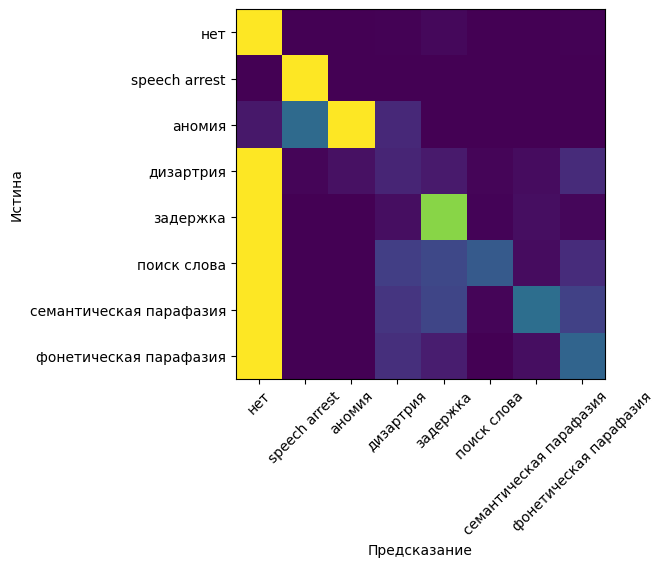

In [ ]:
X = dataset_2[['Stimulus', 'Response_annot',
               'RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']

new_pipeline = Pipeline([
        ('counter', EditopsCounter(X.columns)),
        ('classifier', DecisionTreeClassifier(random_state=SEED))
])

_ = evaluate(X, y, new_pipeline)


Класс			Prec.	Rec.	F1
нет			0.1329	0.1345	0.1292
аномия			0.7848	0.8250	0.7989
дизартрия		0.3406	0.3299	0.3349
задержка		0.7585	0.7616	0.7598
поиск слова		0.2868	0.2927	0.2793
семантическая парафазия	0.3601	0.2676	0.2969
фонетическая парафазия	0.4196	0.4490	0.4319


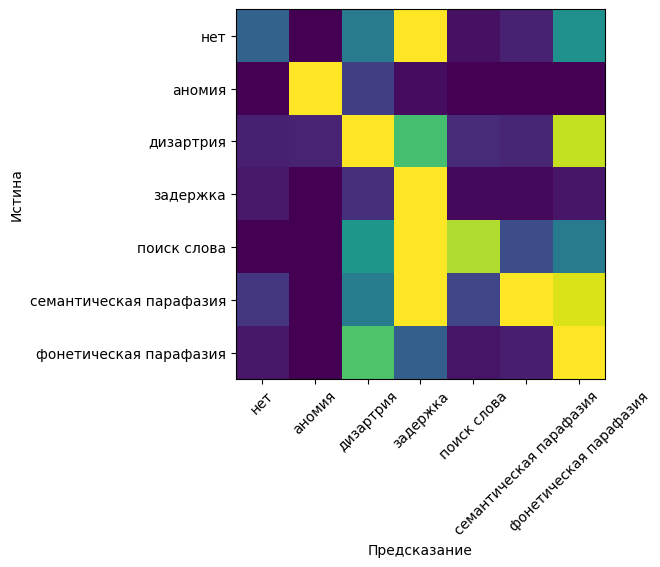

In [81]:
X = dataset_2_t[['Stimulus', 'Response_annot',
               'RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements',
               'insertions_transcription',
               'deletions_transcription',
               'replacements_transcription']]
y = dataset_2_t['error_type_label']

new_pipeline = Pipeline([
        ('counter', EditopsCounter(X.columns)),
        ('classifier', DecisionTreeClassifier(random_state=SEED))
])

_ = evaluate(X, y, new_pipeline)


# Положение ответов в языке

До этого я анализировал только то, как ответ соотносится со стимулом. Тем не менее, семантическую и фонетическую парафазию нельзя определить в отрыве от всего остального языка, в частности, так не делалось при человеческой разметке.

## Формальная близость к настоящим словам

Предполагается, что если ответ формально близок к какому-либо существующему слову и далёк от стимула — то это семантическая парафазия, если ближе к стимулу — то фонетическая.

Будем использовать наиболее частотные существительные и глагольные формы по НКРЯ. Будет определяться расстояние Левенштейна между ответом, стимулом и ближайшим к ответу словом из НКРЯ. Также учитывается разность логарифмов частотностей кандидата в ответы и стимула. Это нужно, чтобы исключить ложное попадание в слишком редкое или слишком частотное слово при фактической фонетической парафазии; также предполагается, что при семантической парафазии заменяющее слово будет примерно так же частотно, как стимул.

In [ ]:
RNC_concrete_nouns_N = pl.read_csv('../data/RNC/concrete_nouns_N.csv',
                                    separator=';')

RNC_verbs_praes_sg_3p = pl.read_csv(
                                '../data/RNC/verbs_praes_sg_3p.csv', separator=';')

verbs_praes_sg_3p_lemmata = pl.read_csv(
                            '../data/RNC/verbs_praes_sg_3p_lemmata.csv', separator=';')

RNC_stimuli_forms = RNC_concrete_nouns_N.vstack(
    verbs_praes_sg_3p_lemmata)

RNC_stimuli_forms = RNC_stimuli_forms.with_columns(
                                    pl.col('ipm').log10()
                                )[['word_0', 'ipm']]

RNC_response_forms = RNC_concrete_nouns_N.vstack(RNC_verbs_praes_sg_3p)

RNC_response_forms = RNC_response_forms.with_columns(
                                    pl.col('ipm').log10()
                                )[['word_0', 'ipm']]


In [ ]:
pl.concat([
    dataset['Stimulus']\
        .filter(~dataset['Stimulus']\
        .is_in(RNC_stimuli_forms['word_0']))
]).unique().to_list()
